### Example 7.1: An Application of Euler's Method 

Apply Euler's method to solve:

$\frac{ \mathrm{d} y } { \mathrm{d} x } = -xy$ with initial condition $y(0) = 1$ from $x=0$ to $x=3$.

Use various step sizes: $h=0.500, 0.200, 0.100, 0.050, 0.020, 0.010, 0.005, 0.002, 0.001$ and calculate the error relative to the analytical solution $y(x) = \exp{(-x^2/2)}$ at the points $x=1$ and $x=3$. Does it scale as you expect with $h$? 

Plot the $y(x)$ for a few step sizes, e.g. $h=0.500, 0.050, 0.001$, as well as the analytical function.

In [7]:
import numpy as np

# define the generic Euler method function

# f(x,y) defines the problem along with the initial condition y(x=0) = y0
# xmax is the point where we want to stop and get y(x)
def EulerMethod(func, y0, xmax, h):
    """This implements the Euler method for solving 1st order ODEs"""
    # first get number of subintervals
    N = int(xmax/h)
    yns = [] # list that contains the values of yn's
    xns = [] # list that contains the values of xn's
    # append the starting values (initial condition: y(x=0) = y0)
    yns.append(y0)
    xns.append(0)
    # start a loop and calculate yn recursively starting at y0
    for n in range(N):
        ynp1 = yns[n] + h * func(xns[n], yns[n])
        yns.append(ynp1)
        xns.append((n+1)*h)
    return yns, xns
    
def func_example71(x,y):
    """The function that defines the Example 7.1"""
    return -x*y

y0 = 1
xmax = 3
h = 0.001
ytest, xtest = EulerMethod(func_example71, y0, xmax, h)
print('Testing the Euler Method for h = 0.001 at x=3', ytest[-1], 'vs analytic', np.exp(-xmax**2/2))
# integrate for h = 0.500, 0.200, 0.100, 0.050, 0.020, 0.010, 0.005, 0.002, 0.001
hlist = [0.500, 0.200, 0.100, 0.050, 0.020, 0.010, 0.005, 0.002, 0.001]
for hi in hlist:
    ytest, xtest = EulerMethod(func_example71, y0, xmax, hi)
    print('Error of Euler Method for h =', hi, 'at x=3', abs(ytest[-1]-np.exp(-xmax**2/2)))

# change xmax to 1
xmax = 1
for hi in hlist:
    ytest, xtest = EulerMethod(func_example71, y0, xmax, hi)
    print('Error of Euler Method for h =', hi, 'at x=1', abs(ytest[-1]-np.exp(-xmax**2/2)))

xmax = 3 
y05, x05 = EulerMethod(func_example71, y0, xmax, 0.5)
y005, x005 = EulerMethod(func_example71, y0, xmax, 0.05)
y0001, x0001 = EulerMethod(func_example71, y0, xmax, 0.001)


Testing the Euler Method for h = 0.001 at x=3 0.011075669560870015 vs analytic 0.011108996538242306
Error of Euler Method for h = 0.5 at x=3 0.011108996538242306
Error of Euler Method for h = 0.2 at x=3 0.006519315386243486
Error of Euler Method for h = 0.1 at x=3 0.003317899401184505
Error of Euler Method for h = 0.05 at x=3 0.0016646717622561726
Error of Euler Method for h = 0.02 at x=3 0.0006664383389156786
Error of Euler Method for h = 0.01 at x=3 0.00033325744836547495
Error of Euler Method for h = 0.005 at x=3 0.00016663340643583748
Error of Euler Method for h = 0.002 at x=3 6.665388110941098e-05
Error of Euler Method for h = 0.001 at x=3 3.332697737229093e-05
Error of Euler Method for h = 0.5 at x=1 0.14346934028736658
Error of Euler Method for h = 0.2 at x=1 0.04633078028736648
Error of Euler Method for h = 0.1 at x=1 0.02162584984266136
Error of Euler Method for h = 0.05 at x=1 0.010453177958645754
Error of Euler Method for h = 0.02 at x=1 0.00409791703036011
Error of Euler Me

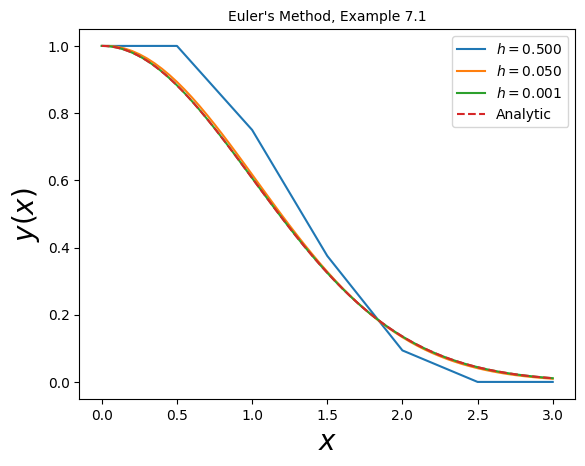

In [9]:
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

# create a NumPy array from 0 to 3
x = np.linspace(0, 3, 300) 

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$x$', fontsize=20) # set the x label
ax.set_ylabel(r'$y(x)$', fontsize=20) # set the y label. Note that the 'r' is necessary to remove the need for double slashes. You can use LaTeX! 
ax.set_title("Euler's Method, Example 7.1", fontsize=10) # set the title 

# make a one-dimensional plot using the above arrays, add a custom label
ax.plot(x05, y05, label='$h=0.500$') 
ax.plot(x005, y005, label='$h=0.050$') 
ax.plot(x0001, y0001, label='$h=0.001$') 

# plot the analytic result:
yanalytic = np.exp(-np.power(x,2)/2)
ax.plot(x, yanalytic, label='Analytic', ls='--') 


# construct the legend:
ax.legend(loc='upper right')  # Add a legend


plt.show()